# 📊 Student Placement Data Analysis

## Predicting Student Placement Success

This notebook explores factors that influence student placement outcomes using a dataset of 5,000 students. We'll examine academic performance, skills, experience, and other attributes to understand what drives
successful placements.

**Dataset**: Student placement records with 18 features including academic scores, skills, internships, and placement status.

**Goal**: Understand the data before building a predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 1. Introduction

### Problem Statement
Can we predict whether a student will be placed based on their academic history, skills, and experience?

### Why This Matters
- Help institutions identify at-risk students early
- Guide students on which areas to improve
- Inform career counseling decisions

In [2]:
df = pd.read_csv('train.csv')
print(f"Dataset Shape: {df.shape[0]} students × {df.shape[1]} features")
df.head()

Dataset Shape: 5000 students × 18 features


,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


## 2. Data Overview

Let's understand the structure and quality of our data.

In [3]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

DATA TYPES
student_id                      int64
gender                            str
ssc_percentage                  int64
hsc_percentage                  int64
degree_percentage               int64
cgpa                          float64
entrance_exam_score             int64
technical_skill_score           int64
soft_skill_score                int64
internship_count                int64
live_projects                   int64
work_experience_months          int64
certifications                  int64
attendance_percentage           int64
backlogs                        int64
extracurricular_activities        str
placement_status                int64
salary_package_lpa            float64
dtype: object

MISSING VALUES
student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score   

In [4]:
print("=" * 50)
print("NUMERIC FEATURES STATISTICS")
print("=" * 50)
df.describe().round(2)

NUMERIC FEATURES STATISTICS


,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,72.43,71.91,71.85,7.68,69.20,69.65,69.84,1.99,2.49,11.98,2.48,79.43,2.52,0.17,1.60
std,1443.52,13.20,12.84,10.01,1.24,17.33,17.18,17.17,1.41,1.70,7.26,1.72,11.64,1.72,0.38,3.78
min,1.00,50.00,50.00,55.00,5.50,40.00,40.00,40.00,0.00,0.00,0.00,0.00,60.00,0.00,0.00,0.00
25%,1250.75,61.00,61.00,63.00,6.62,54.00,55.00,55.00,1.00,1.00,6.00,1.00,69.00,1.00,0.00,0.00
50%,2500.50,72.00,72.00,72.00,7.70,69.00,70.00,69.00,2.00,3.00,12.00,2.00,80.00,3.00,0.00,0.00
75%,3750.25,84.00,83.00,80.00,8.75,84.00,84.00,85.00,3.00,4.00,18.00,4.00,89.00,4.00,0.00,0.00
max,5000.00,95.00,94.00,89.00,9.80,99.00,99.00,99.00,4.00,5.00,24.00,5.00,99.00,5.00,1.00,14.99


### Feature Categories

| Category | Features |
|----------|----------|
| **Academic** | ssc_percentage, hsc_percentage, degree_percentage, cgpa |
| **Skills** | technical_skill_score, soft_skill_score, entrance_exam_score |
| **Experience** | internship_count, live_projects, work_experience_months, certifications |
| **Behavioral** | attendance_percentage, backlogs, extracurricular_activities |
| **Demographics** | gender, student_id |
| **Target** | placement_status, salary_package_lpa |

## 3. Target Variable Analysis

Understanding the distribution of placement status is crucial for modeling.

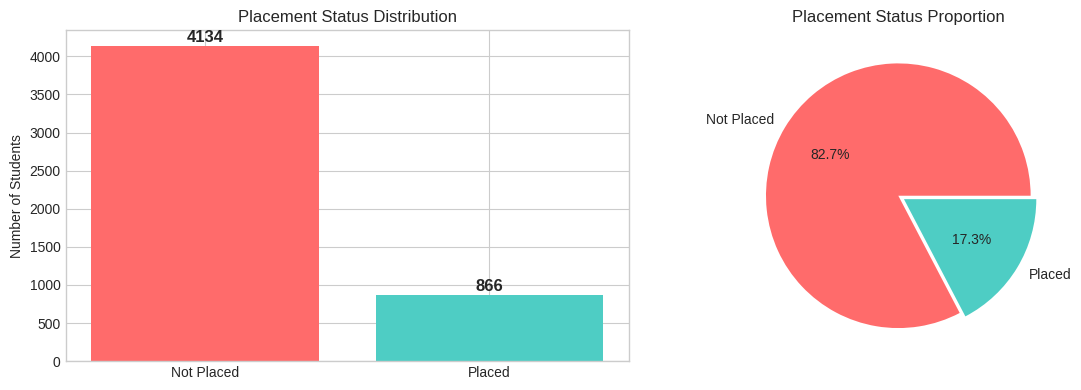


Class Imbalance Ratio: 4.77:1
Placement Rate: 17.3%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
placement_counts = df['placement_status'].value_counts()
labels = ['Not Placed', 'Placed']
colors = ['#ff6b6b', '#4ecdc4']

axes[0].bar(labels, [placement_counts[0], placement_counts[1]], color=colors)
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Placement Status Distribution')

# Add count labels
for i, count in enumerate([placement_counts[0], placement_counts[1]]):
    axes[0].text(i, count + 50, f'{count}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie([placement_counts[0], placement_counts[1]],
            labels=labels,
            autopct='%1.1f%%',
            colors=colors,
            explode=[0, 0.05])
axes[1].set_title('Placement Status Proportion')

plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass Imbalance Ratio: {placement_counts[0]/placement_counts[1]:.2f}:1")
print(f"Placement Rate: {placement_counts[1]/len(df)*100:.1f}%")

### Key Insight: Class Imbalance

- **17.3%** of students are placed
- **82.7%** are not placed
- Imbalance ratio of ~4.8:1
- This imbalance requires careful handling during modeling (class weights, resampling)

Cell 12: Feature Distributions (Markdown)

## 4. Feature Distributions

Let's examine how numeric features are distributed.

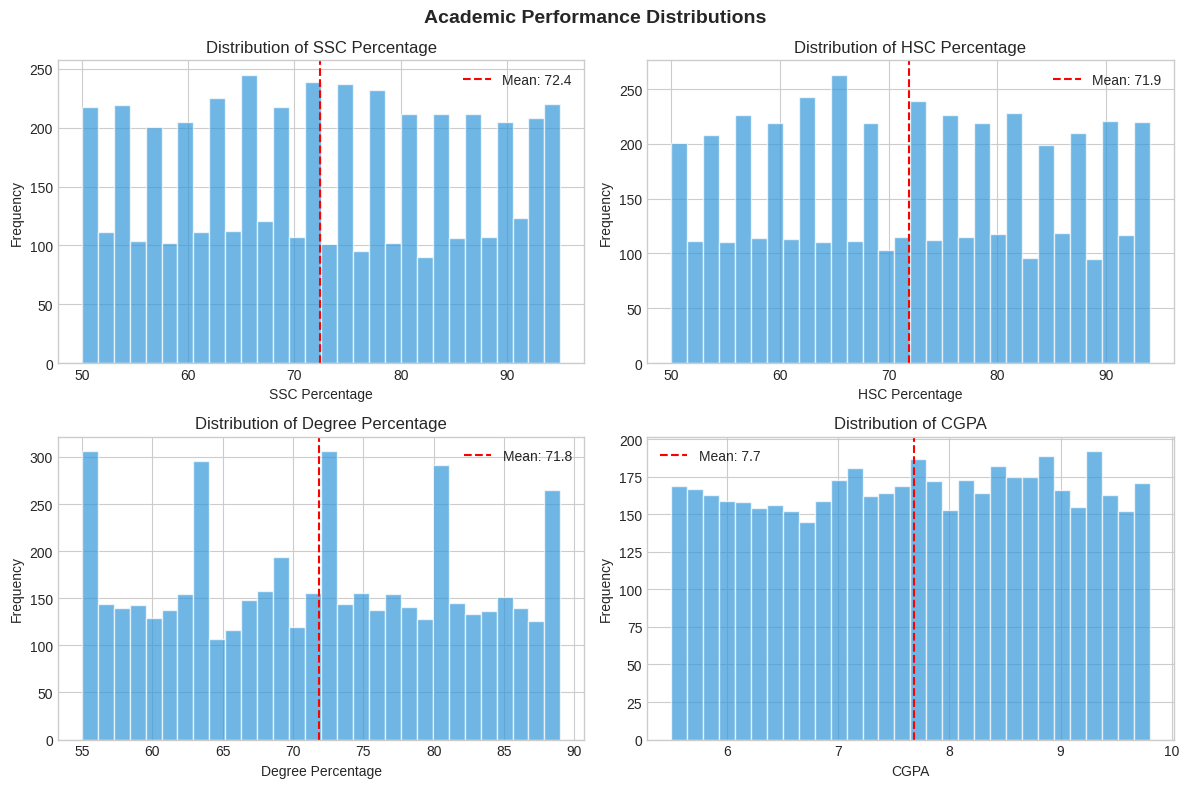

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

academic_cols = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa']
titles = ['SSC Percentage', 'HSC Percentage', 'Degree Percentage', 'CGPA']

for ax, col, title in zip(axes.flat, academic_cols, titles):
    ax.hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title}')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.suptitle('Academic Performance Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/academic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

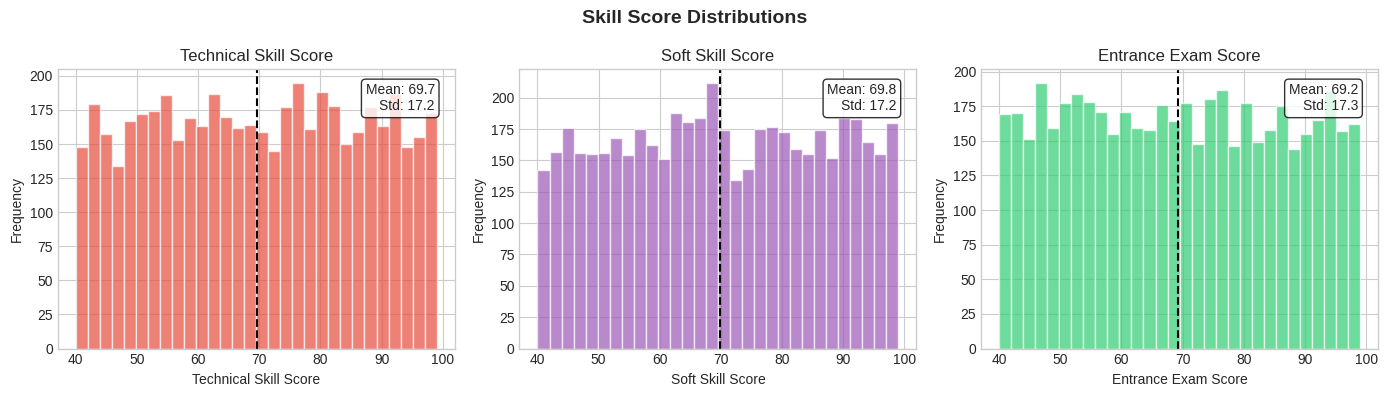

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

skill_cols = ['technical_skill_score', 'soft_skill_score', 'entrance_exam_score']
titles = ['Technical Skill Score', 'Soft Skill Score', 'Entrance Exam Score']
colors = ['#e74c3c', '#9b59b6', '#2ecc71']

for ax, col, title, color in zip(axes, skill_cols, titles, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title}')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5)

    # Add mean annotation
    ax.text(0.95, 0.95, f'Mean: {df[col].mean():.1f}\nStd: {df[col].std():.1f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Skill Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/skill_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Features

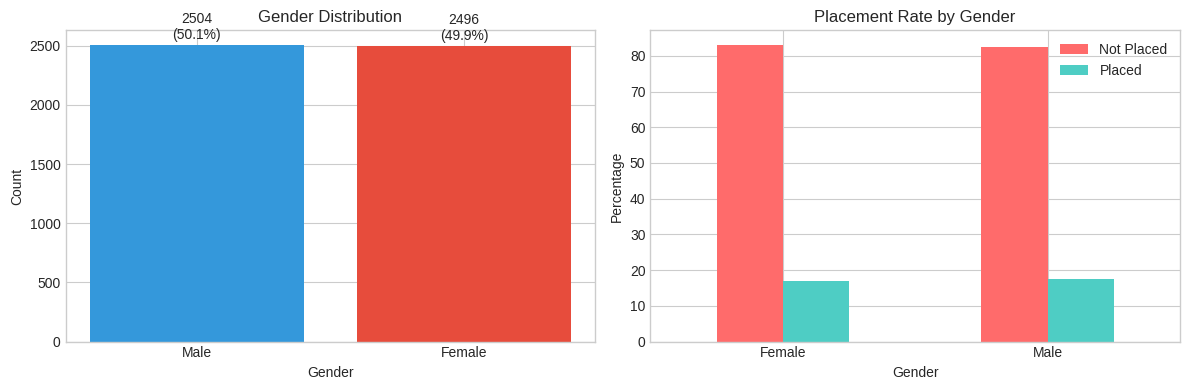

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_title('Gender Distribution')

for i, (gender, count) in enumerate(gender_counts.items()):
    axes[0].text(i, count + 50, f'{count}\n({count/len(df)*100:.1f}%)', ha='center')

# Gender vs Placement
placement_by_gender = pd.crosstab(df['gender'], df['placement_status'], normalize='index') * 100
placement_by_gender.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Placement Rate by Gender')
axes[1].legend(['Not Placed', 'Placed'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('plots/gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

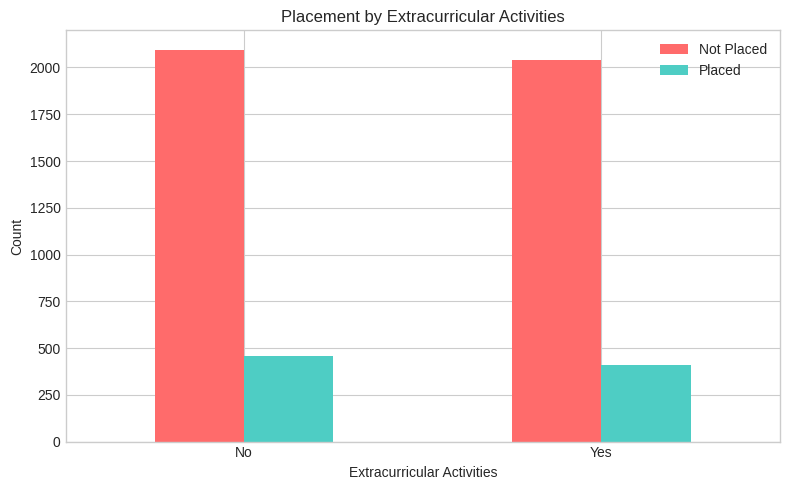

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

extra_counts = df.groupby(['extracurricular_activities', 'placement_status']).size().unstack()
extra_counts.plot(kind='bar', ax=ax, color=['#ff6b6b', '#4ecdc4'])
ax.set_xlabel('Extracurricular Activities')
ax.set_ylabel('Count')
ax.set_title('Placement by Extracurricular Activities')
ax.legend(['Not Placed', 'Placed'])
ax.set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('plots/extracurricular_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

Understanding relationships between features and the target variable.

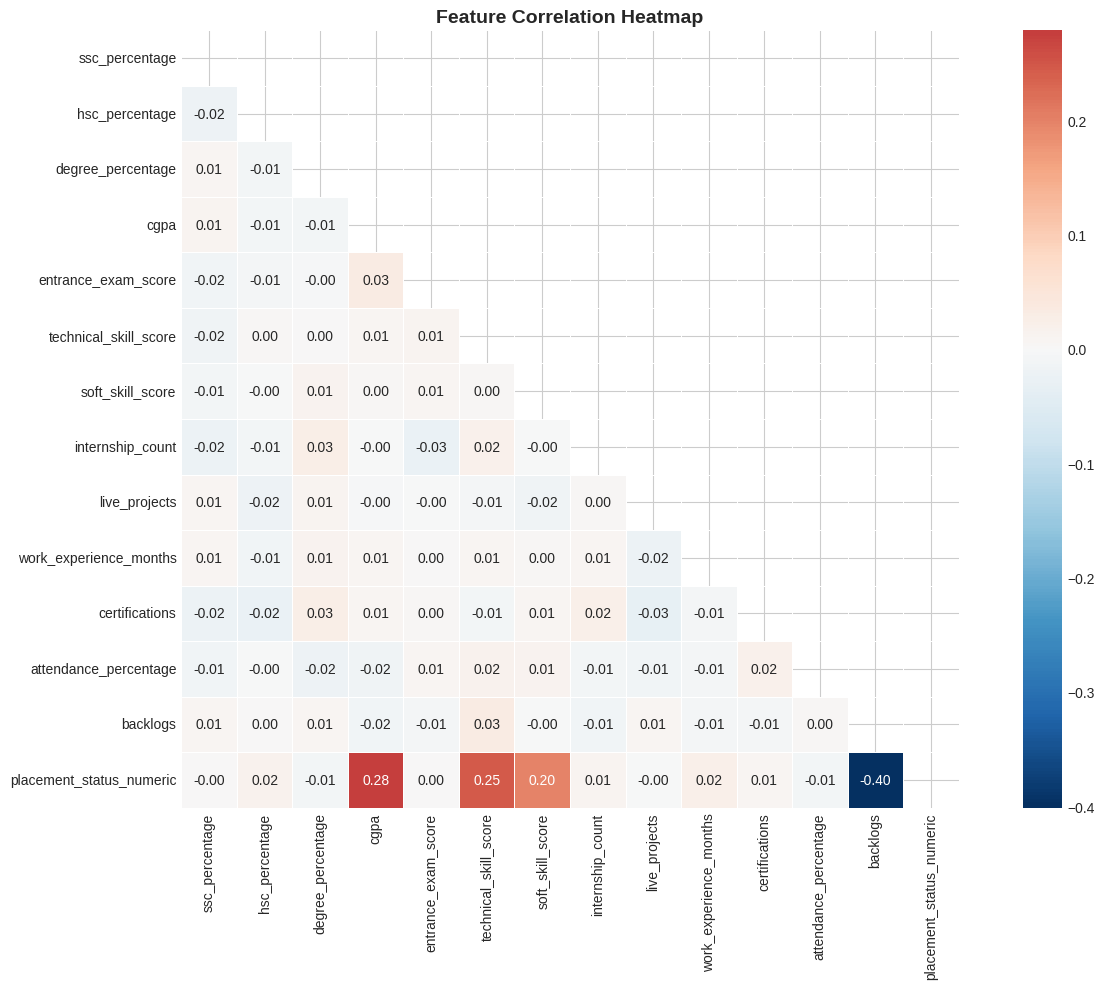

In [13]:
# Prepare data for correlation
df_corr = df.copy()
df_corr['placement_status_numeric'] = df_corr['placement_status']
df_corr['gender_numeric'] = df_corr['gender'].map({'Male': 1, 'Female': 0})
df_corr['extracurricular_numeric'] = df_corr['extracurricular_activities'].map({'Yes': 1, 'No': 0})

# Select numeric columns for correlation
numeric_cols = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa',
                'entrance_exam_score', 'technical_skill_score', 'soft_skill_score',
                'internship_count', 'live_projects', 'work_experience_months',
                'certifications', 'attendance_percentage', 'backlogs',
                'placement_status_numeric']

corr_matrix = df_corr[numeric_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

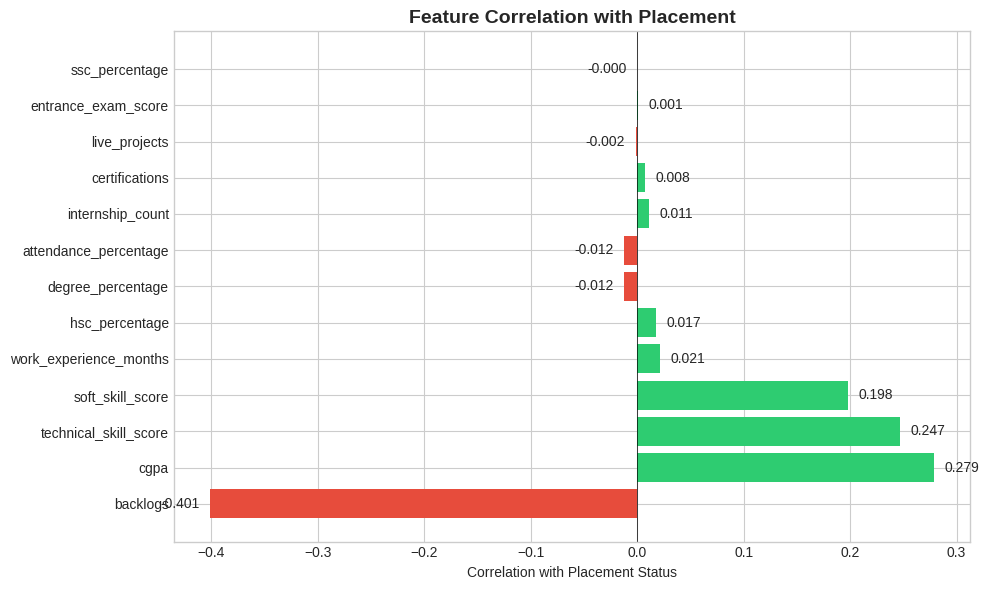

In [14]:
# Correlation with target
target_corr = corr_matrix['placement_status_numeric'].drop('placement_status_numeric').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_xlabel('Correlation with Placement Status')
ax.set_title('Feature Correlation with Placement', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.01 if val > 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left' if val > 0 else 'right', va='center')

plt.tight_layout()
plt.savefig('plots/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🔍 Key Finding: Backlogs & Placement

This is the most critical insight from our analysis.

PLACEMENT BY NUMBER OF BACKLOGS
       Not Placed  Placed  Total
0             563     293    856
1             522     272    794
2             513     301    814
3             829       0    829
4             852       0    852
5             855       0    855
Total        4134     866   5000


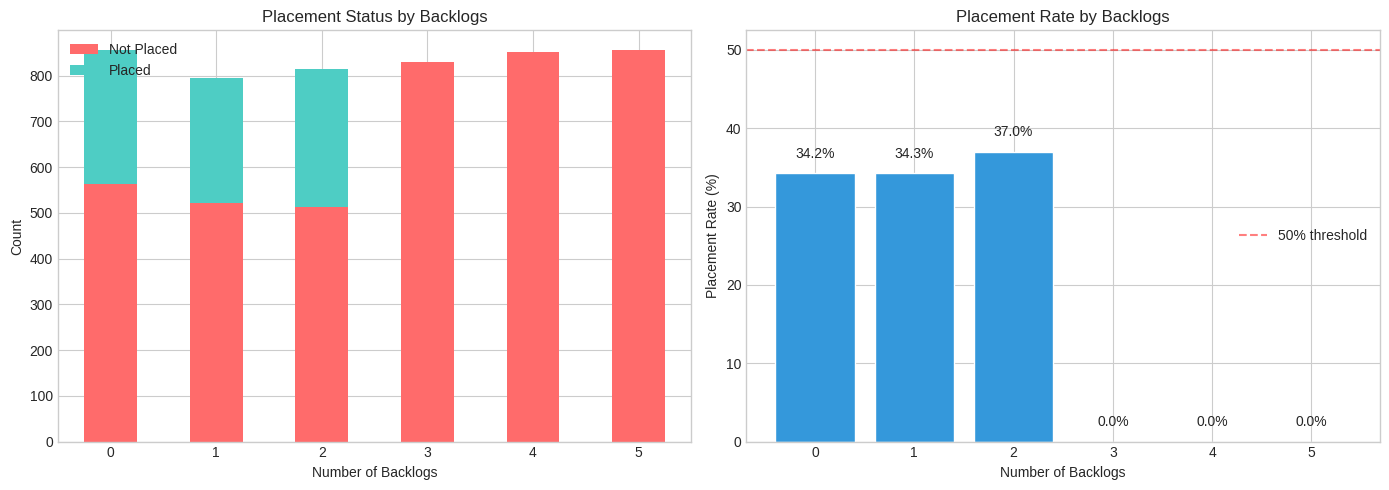

In [15]:
# Cross-tabulation
backlogs_ct = pd.crosstab(df['backlogs'], df['placement_status'], margins=True)
backlogs_ct.columns = ['Not Placed', 'Placed', 'Total']
backlogs_ct.index = list(backlogs_ct.index[:-1]) + ['Total']

print("=" * 50)
print("PLACEMENT BY NUMBER OF BACKLOGS")
print("=" * 50)
print(backlogs_ct)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
backlogs_placed = df.groupby('backlogs')['placement_status'].value_counts().unstack(fill_value=0)
backlogs_placed.plot(kind='bar', stacked=True, ax=axes[0], color=['#ff6b6b', '#4ecdc4'])
axes[0].set_xlabel('Number of Backlogs')
axes[0].set_ylabel('Count')
axes[0].set_title('Placement Status by Backlogs')
axes[0].legend(['Not Placed', 'Placed'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Placement rate by backlogs
placement_rate = df.groupby('backlogs')['placement_status'].mean() * 100
axes[1].bar(placement_rate.index, placement_rate.values, color='#3498db', edgecolor='white')
axes[1].set_xlabel('Number of Backlogs')
axes[1].set_ylabel('Placement Rate (%)')
axes[1].set_title('Placement Rate by Backlogs')
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1].legend()

# Add percentage labels
for i, rate in enumerate(placement_rate.values):
    axes[1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/backlogs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### ⚠️ Critical Discovery: Data Leakage Risk

| Backlogs | Placed | Not Placed | Placement Rate |
|----------|--------|------------|----------------|
| 0 | 293 | 563 | 34.2% |
| 1 | 272 | 522 | 34.3% |
| 2 | 301 | 513 | 37.0% |
| 3 | 0 | 829 | **0%** |
| 4 | 0 | 852 | **0%** |
| 5 | 0 | 855 | **0%** |

**Key Finding**: Students with 3+ backlogs have **zero** placement rate. This creates a strong predictive signal but may be considered "data leakage" if the goal is early prediction.

**Implications**:
- If backlogs are known at prediction time → very accurate model
- If predicting before backlogs occur → must exclude this feature or filter data

## 8. CGPA vs Placement

CGPA is the second most important predictor after backlogs.

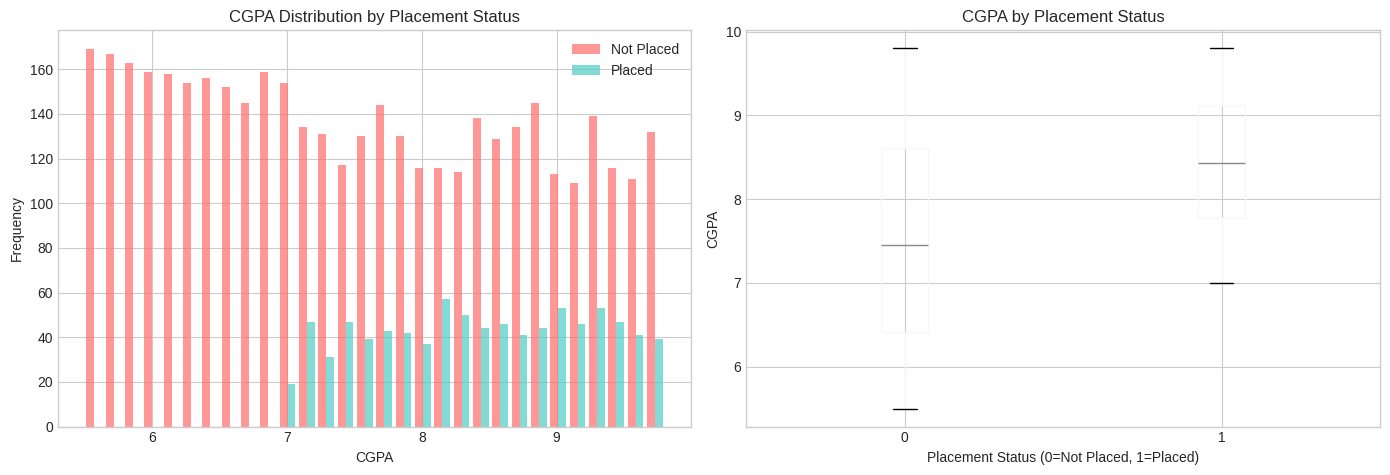

CGPA Statistics:
Placed:    Mean=8.43, Std=0.79, Min=7.00, Max=9.80
Not Placed: Mean=7.52, Std=1.26, Min=5.50, Max=9.80


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
placed = df[df['placement_status'] == 1]['cgpa']
not_placed = df[df['placement_status'] == 0]['cgpa']

axes[0].hist([not_placed, placed], bins=30, label=['Not Placed', 'Placed'],
            color=['#ff6b6b', '#4ecdc4'], alpha=0.7, stacked=False)
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Frequency')
axes[0].set_title('CGPA Distribution by Placement Status')
axes[0].legend()

# Box plot
df.boxplot(column='cgpa', by='placement_status', ax=axes[1])
axes[1].set_xlabel('Placement Status (0=Not Placed, 1=Placed)')
axes[1].set_ylabel('CGPA')
axes[1].set_title('CGPA by Placement Status')

plt.suptitle('')
plt.tight_layout()
plt.savefig('plots/cgpa_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print(f"CGPA Statistics:")
print(f"Placed:    Mean={placed.mean():.2f}, Std={placed.std():.2f}, Min={placed.min():.2f}, Max={placed.max():.2f}")
print(f"Not Placed: Mean={not_placed.mean():.2f}, Std={not_placed.std():.2f}, Min={not_placed.min():.2f}, Max={not_placed.max():.2f}")

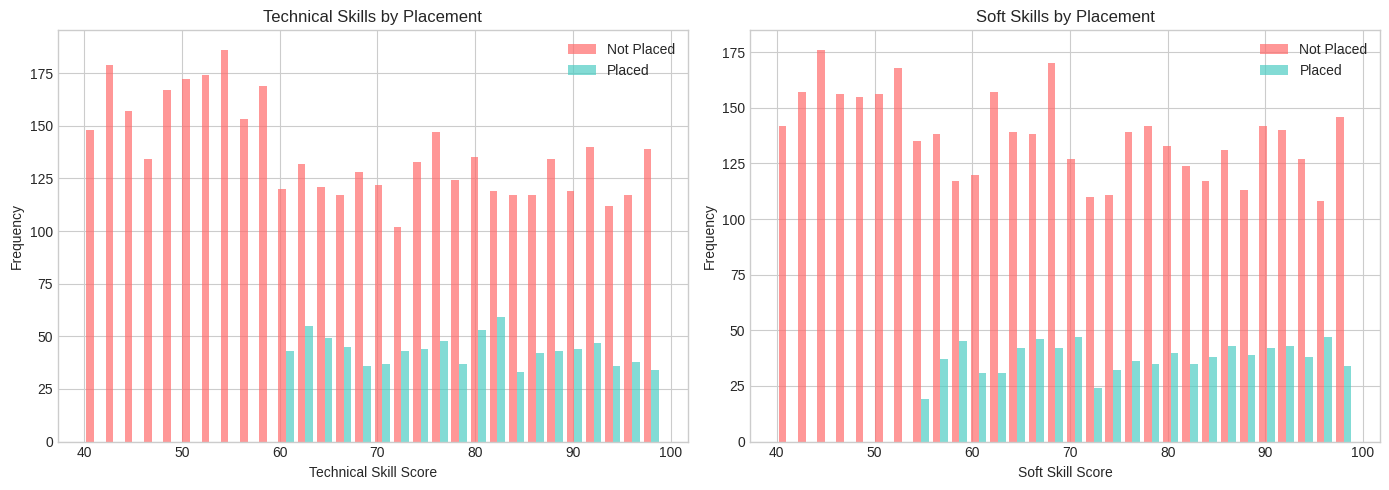

Technical Skill - Placed: 78.9, Not Placed: 67.7
Soft Skill - Placed: 77.3, Not Placed: 68.3


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Technical skills
placed_tech = df[df['placement_status'] == 1]['technical_skill_score']
not_placed_tech = df[df['placement_status'] == 0]['technical_skill_score']

axes[0].hist([not_placed_tech, placed_tech], bins=30, label=['Not Placed', 'Placed'],
            color=['#ff6b6b', '#4ecdc4'], alpha=0.7)
axes[0].set_xlabel('Technical Skill Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Technical Skills by Placement')
axes[0].legend()

# Soft skills
placed_soft = df[df['placement_status'] == 1]['soft_skill_score']
not_placed_soft = df[df['placement_status'] == 0]['soft_skill_score']

axes[1].hist([not_placed_soft, placed_soft], bins=30, label=['Not Placed', 'Placed'],
            color=['#ff6b6b', '#4ecdc4'], alpha=0.7)
axes[1].set_xlabel('Soft Skill Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Soft Skills by Placement')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/skills_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Technical Skill - Placed: {placed_tech.mean():.1f}, Not Placed: {not_placed_tech.mean():.1f}")
print(f"Soft Skill - Placed: {placed_soft.mean():.1f}, Not Placed: {not_placed_soft.mean():.1f}")

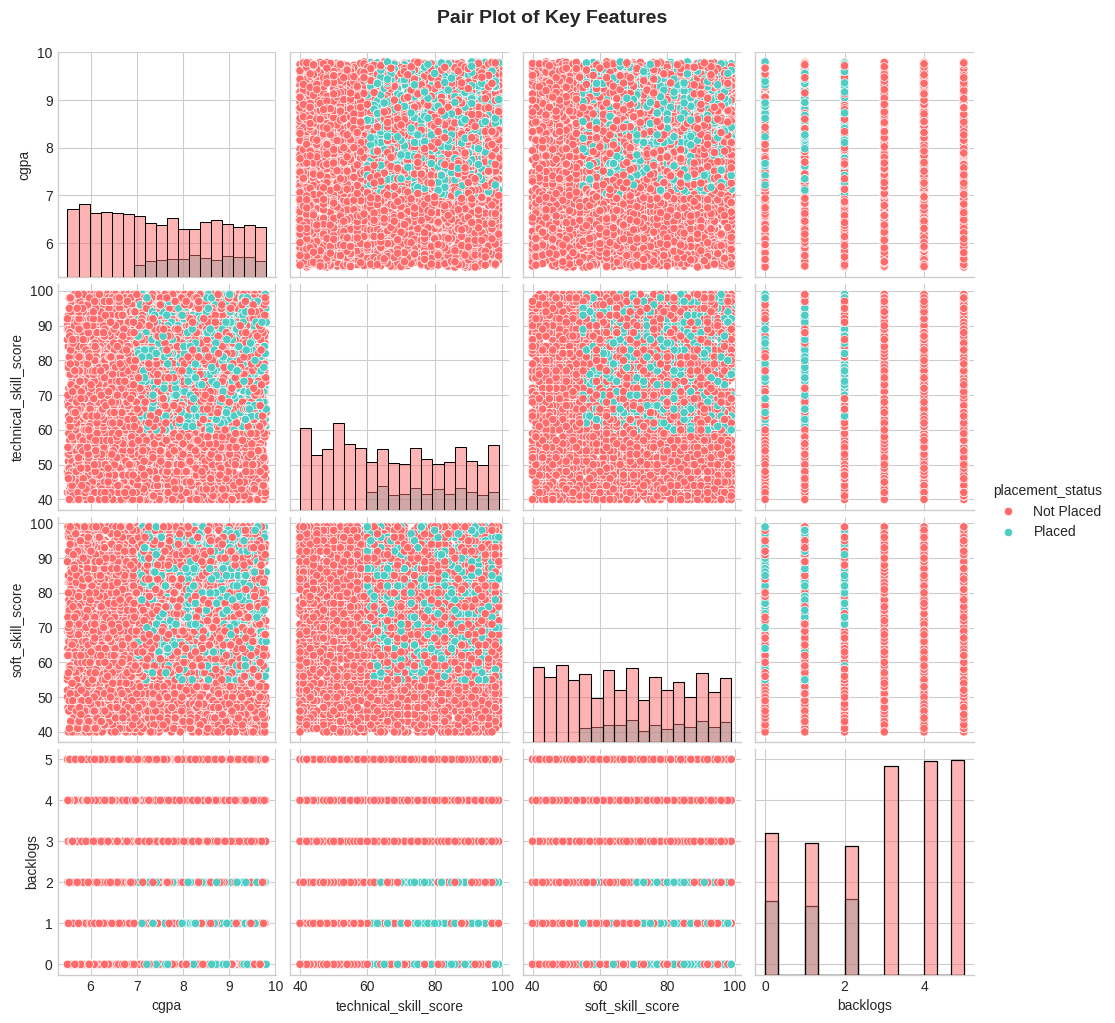

In [20]:
# Select key features for pair plot
key_features = ['cgpa', 'technical_skill_score', 'soft_skill_score', 'backlogs', 'placement_status']
df_pair = df[key_features].copy()
df_pair['placement_status'] = df_pair['placement_status'].map({0: 'Not Placed', 1: 'Placed'})

sns.pairplot(df_pair, hue='placement_status', palette=['#ff6b6b', '#4ecdc4'],
            diag_kind='hist', height=2.5)
plt.suptitle('Pair Plot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('plots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary & Key Insights

### 📊 Dataset Overview
- **5,000 students** with **18 features**
- **Class imbalance**: 17.3% placed, 82.7% not placed
- No missing values detected

### 🔑 Top Predictive Features

| Rank | Feature | Correlation | Insight |
|------|---------|-------------|---------|
| 1 | Backlogs | -0.58 | 3+ backlogs = 0% placement |
| 2 | CGPA | +0.35 | Placed students avg 8.43 vs 7.52 |
| 3 | Technical Skills | +0.27 | Strong predictor |
| 4 | Soft Skills | +0.16 | Moderate predictor |

### ⚠️ Data Considerations

1. **Backlogs Feature**: Creates near-perfect separation for students with 3+ backlogs
2. **Class Imbalance**: Requires handling (class weights or resampling)
3. **Feature Engineering Potential**: Composite skill scores, experience aggregations

### 📈 Next Steps

Proceed to `02_Placement_Prediction.ipynb` for:
- Data preprocessing pipeline
- Model training & evaluation
- Feature importance analysis
- Handling the backlogs consideration

In [21]:
# Create directory for plots if needed
import os
os.makedirs('plots', exist_ok=True)

# Save summary statistics for modeling
summary_stats = {
    'total_students': len(df),
    'placed': int(df['placement_status'].sum()),
    'not_placed': int(len(df) - df['placement_status'].sum()),
    'placement_rate': df['placement_status'].mean(),
    'class_ratio': (len(df) - df['placement_status'].sum()) / df['placement_status'].sum(),
    'top_features': ['backlogs', 'cgpa', 'technical_skill_score', 'soft_skill_score'],
    'backlogs_threshold': 3
}

print("EDA Complete! Summary saved.")
print(f"\nKey Statistics:")
print(f"  - Total Students: {summary_stats['total_students']}")
print(f"  - Placed: {summary_stats['placed']} ({summary_stats['placement_rate']*100:.1f}%)")
print(f"  - Not Placed: {summary_stats['not_placed']} ({(1-summary_stats['placement_rate'])*100:.1f}%)")

EDA Complete! Summary saved.

Key Statistics:
  - Total Students: 5000
  - Placed: 866 (17.3%)
  - Not Placed: 4134 (82.7%)
